# Dynamic Sign Recognition — InceptionV4 Architecture
MediaPipe Hands → InceptionV4 spatial features → Transformer temporal classifier

In [1]:
# ────────────────────────────────────────────────────────────────────────────────
# 1 Install required packages
# ────────────────────────────────────────────────────────────────────────────────
from collections import deque
import subprocess
import sys

packages = [
    'torch',
    'torchvision',
    'timm',
    'mediapipe',
    'opencv-python',
    'numpy',
    'pandas',
    'matplotlib',
    'scikit-learn',
    'tqdm',
    'kagglehub'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✓ All packages installed')

✓ All packages installed


In [2]:
# ────────────────────────────────────────────────────────────────────────────────
# 2 Imports and CUDA check
# ────────────────────────────────────────────────────────────────────────────────
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import cv2
import timm
from timm.models import create_model
from tqdm import tqdm
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from torchvision import transforms
import warnings
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')
    print(f'CUDA capability: {torch.cuda.get_device_capability(0)}')
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
else:
    print('WARNING: CUDA not available, will use CPU (slow)')

c:\Users\johnr\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA capability: (8, 6)


In [3]:
# ────────────────────────────────────────────────────────────────────────────────
# 3 Global configuration & dataset path resolution
# ────────────────────────────────────────────────────────────────────────────────

import kagglehub
from pathlib import Path

# Download/get the IPN dataset root dynamically
print("Downloading IPN Hand Dataset (if not cached)...")
_DATASET_ROOT_STR = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
_DATASET_ROOT = Path(_DATASET_ROOT_STR)
print(f"Dataset root: {_DATASET_ROOT}")

# Set working directory to script's folder (safe for multiple architecture folders)
os.chdir(os.path.dirname(os.path.abspath('inceptionv4_notebook.ipynb')) or '.')
print(f'Working directory: {os.getcwd()}')

# ────── Helper functions for annotation loading ──────
def _find_annotation_file(root: Path) -> Path:
    """Find annotation file in dataset hierarchy."""
    for search_root in [root / "annotations" / "annotations", root / "annotations", root]:
        if not search_root.exists():
            continue
        for pattern in ["Annot_TrainList.txt", "Annot_TrainList.csv",
                        "Annot_List.txt", "Annot*.txt", "Annot*.csv"]:
            hits = [p for p in search_root.rglob(pattern)
                    if p.name.lower() != "metadata.csv"]
            if hits:
                return hits[0]
    raise FileNotFoundError(f"No Annot_*List file found under {root}")

def _find_video_dir(root: Path) -> Path:
    """Find video directory in dataset hierarchy."""
    candidates = [
        root / "videos" / "videos",
        root / "videos",
        root
    ]
    for candidate in candidates:
        if candidate.exists():
            # Check if this directory has .avi or .mp4 files
            avi_files = list(candidate.glob("*.avi"))
            mp4_files = list(candidate.glob("*.mp4"))
            if avi_files or mp4_files:
                print(f'  Video dir: {candidate} ({len(avi_files) + len(mp4_files)} videos)')
                return candidate
    raise FileNotFoundError(f"No video directory found under {root}")

def _load_annotations(annot_path: Path) -> pd.DataFrame:
    """Load annotations CSV/TXT file."""
    with open(annot_path) as f:
        first_line = f.readline().strip()
    
    has_header = first_line.lower().startswith("video")
    if has_header:
        df = pd.read_csv(annot_path)
        df = df.rename(columns={"video": "video_name"})
    else:
        df = pd.read_csv(
            annot_path, header=None,
            names=["video_name", "label", "id", "t_start", "t_end", "frames"],
        )
    df["id"] = df["id"].astype(int)
    df["t_start"] = df["t_start"].astype(int)
    df["t_end"] = df["t_end"].astype(int)
    return df[["video_name", "label", "id", "t_start", "t_end"]].dropna()

# Find and load annotations
_ANNOT_FILE = _find_annotation_file(_DATASET_ROOT)
_VIDEO_DIR = _find_video_dir(_DATASET_ROOT)
print(f'✓ Annotation file: {_ANNOT_FILE}')
print(f'✓ Video directory: {_VIDEO_DIR}')

CONFIG = {
    # ────── IPN Dataset Paths ──────
    'IPN_ROOT': str(_DATASET_ROOT),
    'ANNOTATION_FILE': str(_ANNOT_FILE),
    'VIDEO_DIR': str(_VIDEO_DIR),
    
    # ────── Architecture: InceptionV4 ──────
    'BACKBONE': 'inception_v4',
    'FEATURE_DIM': 1536,
    'IMG_SIZE': (299, 299),  # InceptionV4 expects 299x299
    'FREEZE_LAYERS': ['features.0', 'features.1', 'features.2', 'features.3', 
                      'features.4', 'features.5', 'features.6', 'features.7',
                      'features.8', 'features.9', 'features.10', 'features.11',
                      'features.12', 'features.13', 'features.14', 'features.15',
                      'features.16', 'features.17', 'features.18', 'features.19', 'features.20'],
    
    # ────── Gesture class mapping ──────
    'KEEP_IDS': {2, 6, 7, 9, 10},  # 5 gesture classes from annotation file
    'ID_TO_CLASS': {2: 0, 6: 1, 7: 2, 9: 3, 10: 4},
    'CLASS_NAMES': ["B0A Pointing (one finger)", "G03 Throw up", "G04 Throw down", "G06 Throw right", "G07 Open twice"],  # Gesture labels
    
    # ────── Transformer ──────
    'TRANSFORMER_HIDDEN': 256,
    'TRANSFORMER_HEADS': 4,
    'TRANSFORMER_LAYERS': 2,
    'TRANSFORMER_DROPOUT': 0.1,
    'MAX_SEQUENCE_LEN': 16,  # Feature sequence length
    
    # ────── Training ──────
    'BATCH_SIZE': 8,
    'NUM_EPOCHS': 30,
    'LEARNING_RATE': 3e-4,
    'WEIGHT_DECAY': 1e-5,
    'WARMUP_EPOCHS': 5,
    'NUM_WORKERS': 0,
    'PIN_MEMORY': True,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # ────── Data splits ──────
    'TRAIN_SPLIT': 0.7,
    'VAL_SPLIT': 0.15,
    'TEST_SPLIT': 0.15,
    
    # ────── Webcam ──────
    'TRIGGER_FRAMES': 15,

    # ────── Checkpoint & cache ──────
    'CHECKPOINT_DIR': './checkpoints',
    'FEATURE_CACHE_DIR': './feature_cache',
    'HAND_LANDMARKER_MODEL': './hand_landmarker.task',
    
    # ────── Class weights (inverse frequency for loss) ──────
    'CLASS_WEIGHTS': torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float32),
}

# Load annotation DataFrame
_ANNOT_DF = _load_annotations(_ANNOT_FILE)
_ANNOT_DF = _ANNOT_DF[_ANNOT_DF["id"].isin(CONFIG['KEEP_IDS'])].reset_index(drop=True)
print(f'✓ Config loaded: {CONFIG["BACKBONE"]} backbone')
print(f'  Device: {CONFIG["DEVICE"]}')
print(f'  Total clips: {len(_ANNOT_DF)}')

# Create directories
os.makedirs(CONFIG['CHECKPOINT_DIR'], exist_ok=True)
os.makedirs(CONFIG['FEATURE_CACHE_DIR'], exist_ok=True)

Dataset root: C:\Users\johnr\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7
Working directory: c:\Users\johnr\Documents\dsp-dynamic-sign-recognition\inceptionv4
  Video dir: C:\Users\johnr\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7\videos\videos (200 videos)
✓ Annotation file: C:\Users\johnr\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7\annotations\annotations\Annot_TrainList.txt
✓ Video directory: C:\Users\johnr\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7\videos\videos
✓ Config loaded: inception_v4 backbone
  Device: cuda
  Total clips: 1338


In [4]:
# ────────────────────────────────────────────────────────────────────────────────
# 4 IPNDataset: Load gesture clips from annotated video segments
# ────────────────────────────────────────────────────────────────────────────────

def _extract_clip_from_video(video_path: str, t_start: int, t_end: int, img_size: tuple) -> torch.Tensor:
    """Extract and preprocess frames from video segment [t_start, t_end] (1-indexed)."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    
    # Seek to t_start (1-indexed → 0-indexed)
    cap.set(cv2.CAP_PROP_POS_FRAMES, t_start - 1)
    
    frames = []
    for _ in range(t_end - t_start + 1):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        frames.append(frame)
    
    cap.release()
    
    if len(frames) == 0:
        return torch.zeros(1, 3, *img_size)
    
    frames = np.stack(frames, axis=0).astype(np.float32) / 255.0  # (T, H, W, 3)
    frames = torch.from_numpy(frames).permute(0, 3, 1, 2)  # (T, 3, H, W)
    return frames

class IPNDataset(torch.utils.data.Dataset):
    def __init__(self, annot_df: pd.DataFrame, video_dir: str, img_size: tuple, split: str = 'train'):
        self.video_dir = video_dir
        self.img_size = img_size
        self.split = split
        self.annot_df = annot_df.reset_index(drop=True)
        
        # Split by fold: folds 1-3 train, fold 4 val, fold 5 test
        fold_map = {}
        for idx, row in self.annot_df.iterrows():
            video_name = row['video_name']
            # Extract fold: "1CM1_1_R" → fold 1
            try:
                fold = int(video_name.split('_')[1])
                fold_map[idx] = fold
            except:
                fold_map[idx] = 0
        
        if split == 'train':
            self.indices = [i for i, f in fold_map.items() if f in [1, 2, 3]]
        elif split == 'val':
            self.indices = [i for i, f in fold_map.items() if f == 4]
        elif split == 'test':
            self.indices = [i for i, f in fold_map.items() if f == 5]
        else:
            self.indices = list(range(len(self.annot_df)))
        
        print(f'  {split.upper()}: {len(self.indices)} clips (folds {self._get_fold_info(split)})')
    
    def _get_fold_info(self, split):
        if split == 'train': return '1-3'
        elif split == 'val': return '4'
        elif split == 'test': return '5'
        else: return 'all'
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        row = self.annot_df.iloc[real_idx]
        
        # Find video file
        video_name = row['video_name']
        video_path = None
        for ext in ['.avi', '.mp4', '.AVI', '.MP4']:
            candidate = os.path.join(self.video_dir, video_name + ext)
            if os.path.exists(candidate):
                video_path = candidate
                break
        
        if video_path is None:
            # Return blank if video not found
            print(f'⚠ Video not found: {video_name}')
            return torch.zeros(1, 3, *self.img_size), torch.tensor(0)
        
        # Extract clip
        # Extract clip
        frames = _extract_clip_from_video(video_path, row['t_start'], row['t_end'], self.img_size)
        label = CONFIG['ID_TO_CLASS'][int(row['id'])]

        # Normalize all clips to exactly MAX_SEQUENCE_LEN frames
        T = frames.shape[0]
        target = CONFIG['MAX_SEQUENCE_LEN']
        if T >= target:
            indices = torch.linspace(0, T - 1, target).long()
            frames = frames[indices]
        else:
            pad = frames[-1:].repeat(target - T, 1, 1, 1)
            frames = torch.cat([frames, pad], dim=0)

        return frames, torch.tensor(label, dtype=torch.long)

# ── Load datasets ──
print('Loading datasets...')
dataset_train = IPNDataset(_ANNOT_DF, CONFIG['VIDEO_DIR'], CONFIG['IMG_SIZE'], split='train')
dataset_val = IPNDataset(_ANNOT_DF, CONFIG['VIDEO_DIR'], CONFIG['IMG_SIZE'], split='val')
dataset_test = IPNDataset(_ANNOT_DF, CONFIG['VIDEO_DIR'], CONFIG['IMG_SIZE'], split='test')

print(f'✓ Train: {len(dataset_train)} | Val: {len(dataset_val)} | Test: {len(dataset_test)}')

Loading datasets...
  TRAIN: 181 clips (folds 1-3)
  VAL: 73 clips (folds 4)
  TEST: 36 clips (folds 5)
✓ Train: 181 | Val: 73 | Test: 36


In [5]:
# ────────────────────────────────────────────────────────────────────────────────
# 5 InceptionV4FeatureExtractor: Backbone + custom head
# ────────────────────────────────────────────────────────────────────────────────

class InceptionV4FeatureExtractor(nn.Module):
    def __init__(self, device: str = "cpu"):
        super().__init__()
        # Load InceptionV4 from timm with num_classes=0 to get features
        self.backbone = timm.create_model('inception_v4', pretrained=True, num_classes=0)
        
        # Freeze early layers for fine-tuning
        for p in self.backbone.parameters():
            p.requires_grad = False
        
        # Unfreeze later blocks
        for name, p in self.backbone.named_parameters():
            if 'features.20' in name or 'features.21' in name or 'features.22' in name or 'features.23' in name:
                p.requires_grad = True
        
        # Preprocessing pipeline
        self.preprocess = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(CONFIG['IMG_SIZE']),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        
        self.device = device
        n_trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.backbone.parameters())
        print(f"InceptionV4: {n_trainable:,} / {n_total:,} params trainable")
        
        self.to(device)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Process batch of images (B, 3, H, W)."""
        # x is already a tensor in (B, 3, H, W) format
        return self.backbone(x)
    
    @torch.no_grad()
    def encode(self, crop_bgr: np.ndarray) -> torch.Tensor | None:
        """Inference mode (no grad)."""
        if crop_bgr is None or crop_bgr.size == 0:
            return None
        was_training = self.backbone.training
        self.backbone.eval()
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        t = self.preprocess(rgb).unsqueeze(0).to(next(self.backbone.parameters()).device)
        out = self.backbone(t).squeeze(0).cpu()
        if was_training:
            self.backbone.train()
        return out
    
    def encode_train(self, crop_bgr: np.ndarray) -> torch.Tensor | None:
        """Training mode (with grad)."""
        if crop_bgr is None or crop_bgr.size == 0:
            return None
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        t = self.preprocess(rgb).unsqueeze(0).to(next(self.backbone.parameters()).device)
        return self.backbone(t).squeeze(0).cpu()

print('Loading InceptionV4 weights (~50 MB)...')
spatial_extractor = InceptionV4FeatureExtractor(device=CONFIG['DEVICE'])
print(f'✓ InceptionV4 feature extractor ready on {CONFIG["DEVICE"]}')

Loading InceptionV4 weights (~50 MB)...
InceptionV4: 9,106,176 / 41,142,816 params trainable
✓ InceptionV4 feature extractor ready on cuda


In [6]:
# ────────────────────────────────────────────────────────────────────────────────
# 6 TransformerTemporalClassifier: Temporal reasoning on feature sequences
# ────────────────────────────────────────────────────────────────────────────────

class TransformerTemporalClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_dim, num_heads, num_layers, num_classes, dropout=0.1, max_seq_len=64):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        
        # Project features to transformer hidden dim
        self.input_projection = nn.Linear(feature_dim, hidden_dim)
        
        # Positional encoding
        self.positional_encoding = nn.Embedding(max_seq_len, hidden_dim)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, x, mask=None):
        # x: (B, T, feature_dim)
        seq_len = x.shape[1]
        
        # Project to hidden dim
        x = self.input_projection(x)  # (B, T, hidden_dim)
        
        # Add positional encoding
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        pos_enc = self.positional_encoding(positions)  # (1, T, hidden_dim)
        x = x + pos_enc
        
        # Transformer
        x = self.transformer_encoder(x, src_key_padding_mask=mask)  # (B, T, hidden_dim)
        
        # Use CLS token (first element) for classification
        x = x[:, 0, :]  # (B, hidden_dim)
        
        # Classify
        logits = self.classifier(x)  # (B, num_classes)
        return logits

# ── Test ──
test_classifier = TransformerTemporalClassifier(
    feature_dim=CONFIG['FEATURE_DIM'],
    hidden_dim=CONFIG['TRANSFORMER_HIDDEN'],
    num_heads=CONFIG['TRANSFORMER_HEADS'],
    num_layers=CONFIG['TRANSFORMER_LAYERS'],
    num_classes=len(CONFIG['CLASS_NAMES']),
    dropout=CONFIG['TRANSFORMER_DROPOUT'],
    max_seq_len=CONFIG['MAX_SEQUENCE_LEN']
).to(CONFIG['DEVICE'])
print(f'✓ Transformer classifier initialized')
print(f'  Hidden dim: {CONFIG["TRANSFORMER_HIDDEN"]}')
print(f'  Heads: {CONFIG["TRANSFORMER_HEADS"]}')
print(f'  Layers: {CONFIG["TRANSFORMER_LAYERS"]}')

✓ Transformer classifier initialized
  Hidden dim: 256
  Heads: 4
  Layers: 2


In [7]:
# ────────────────────────────────────────────────────────────────────────────────
# 7 DynamicSignModel: End-to-end wrapper
# ────────────────────────────────────────────────────────────────────────────────

class DynamicSignModel(nn.Module):
    def __init__(self, feature_extractor, classifier):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = classifier

    def forward(self, x):
        # x: (B, T, 3, H, W)
        B, T, C, H, W = x.shape
        x = x.reshape(B * T, C, H, W)
        features = self.feature_extractor(x)   # (B*T, feature_dim)
        features = features.reshape(B, T, -1)  # (B, T, feature_dim)
        logits = self.classifier(features)     # (B, num_classes)
        return logits


# Use the spatial_extractor already built in Cell 5
classifier = TransformerTemporalClassifier(
    feature_dim=CONFIG['FEATURE_DIM'],
    hidden_dim=CONFIG['TRANSFORMER_HIDDEN'],
    num_heads=CONFIG['TRANSFORMER_HEADS'],
    num_layers=CONFIG['TRANSFORMER_LAYERS'],
    num_classes=len(CONFIG['CLASS_NAMES']),
    dropout=CONFIG['TRANSFORMER_DROPOUT'],
    max_seq_len=CONFIG['MAX_SEQUENCE_LEN'],
)

model = DynamicSignModel(spatial_extractor, classifier).to(CONFIG['DEVICE'])
print(f'✓ Full model instantiated and moved to {CONFIG["DEVICE"]}')

✓ Full model instantiated and moved to cuda


In [8]:
# ────────────────────────────────────────────────────────────────────────────────
# 8 Training utilities: Metric tracking and epoch functions
# ────────────────────────────────────────────────────────────────────────────────

class AverageMeter:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def train_epoch(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train()
    losses = AverageMeter()
    accuracies = AverageMeter()
    
    with tqdm(total=len(train_loader), desc='Train', leave=False) as pbar:
        for frames, labels in train_loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            if scaler:
                with torch.autocast(device_type='cuda'):
                    logits = model(frames)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(frames)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
            
            # Metrics
            preds = torch.argmax(logits, dim=1)
            acc = (preds == labels).float().mean().item()
            
            losses.update(loss.item(), frames.size(0))
            accuracies.update(acc, frames.size(0))
            
            pbar.update(1)
            pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'acc': f'{accuracies.avg:.4f}'})
    
    return losses.avg, accuracies.avg

def evaluate(model, val_loader, criterion, device):
    model.eval()
    losses = AverageMeter()
    accuracies = AverageMeter()
    
    with torch.no_grad():
        with tqdm(total=len(val_loader), desc='Val', leave=False) as pbar:
            for frames, labels in val_loader:
                frames = frames.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                logits = model(frames)
                loss = criterion(logits, labels)
                
                preds = torch.argmax(logits, dim=1)
                acc = (preds == labels).float().mean().item()
                
                losses.update(loss.item(), frames.size(0))
                accuracies.update(acc, frames.size(0))
                
                pbar.update(1)
                pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'acc': f'{accuracies.avg:.4f}'})
    
    return losses.avg, accuracies.avg

print('✓ Training utilities defined')

✓ Training utilities defined


In [9]:
# ────────────────────────────────────────────────────────────────────────────────
# 9 Full training loop with oversampling (NEW: replaces WeightedRandomSampler)
# ────────────────────────────────────────────────────────────────────────────────

def train(model, train_dataset, val_dataset, config, start_epoch=0):
    device = config['DEVICE']
    num_epochs = config['NUM_EPOCHS']
    batch_size = config['BATCH_SIZE']
    num_workers = config['NUM_WORKERS']
    
    # ────── OVERSAMPLING: Balance minority classes by duplication ──────
    from collections import Counter
    labels_list = [CONFIG['ID_TO_CLASS'][int(train_dataset.annot_df.iloc[train_dataset.indices[i]]['id'])]
               for i in range(len(train_dataset))]
    class_counts = Counter(labels_list)
    max_count = max(class_counts.values())
    
    indices = []
    for idx in range(len(train_dataset)):
        label = labels_list[idx]
        times_to_repeat = max_count // class_counts[label]
        indices.extend([idx] * times_to_repeat)
    
    balanced_train_dataset = Subset(train_dataset, indices)
    
    print(f'Oversampling: {len(train_dataset)} → {len(balanced_train_dataset)} samples')
    print(f'  Class counts (original): {dict(class_counts)}')
    
    # DataLoaders
    train_loader = DataLoader(
        balanced_train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=config['PIN_MEMORY']
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=config['PIN_MEMORY']
    )
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss(weight=config['CLASS_WEIGHTS'].to(device))
    optimizer = optim.AdamW(model.parameters(), lr=config['LEARNING_RATE'], weight_decay=config['WEIGHT_DECAY'])
    
    # Learning rate schedule with warmup
    def get_lr(epoch):
        if epoch < config['WARMUP_EPOCHS']:
            return config['LEARNING_RATE'] * (epoch + 1) / config['WARMUP_EPOCHS']
        else:
            return config['LEARNING_RATE'] * 0.5 ** ((epoch - config['WARMUP_EPOCHS']) // 10)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    scaler = torch.cuda.amp.GradScaler() if device == 'cuda' else None
    torch.cuda.empty_cache()
    
    best_val_acc = 0.0
    checkpoint_path = os.path.join(config['CHECKPOINT_DIR'], 'best_model.pt')
    
    # ────── NEW: Track training history ──────
    training_history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(start_epoch, num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        
        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Record history
        training_history['train_loss'].append(train_loss)
        training_history['train_acc'].append(train_acc)
        training_history['val_loss'].append(val_loss)
        training_history['val_acc'].append(val_acc)
        
        # LR schedule
        scheduler.step()
        
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
        print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # Save best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'temporal_classifier': classifier.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_acc': best_val_acc,
                'backbone': config['BACKBONE'],
                'training_history': training_history,
                'conf_threshold': 0.5,
                'cfg': {
                    'BACKBONE': config['BACKBONE'],
                    'FEATURE_DIM': config['FEATURE_DIM'],
                    'TRANSFORMER_HIDDEN': config['TRANSFORMER_HIDDEN'],
                    'TRANSFORMER_HEADS': config['TRANSFORMER_HEADS'],
                    'TRANSFORMER_LAYERS': config['TRANSFORMER_LAYERS'],
                    'MAX_SEQUENCE_LEN': config['MAX_SEQUENCE_LEN'],
                    'NUM_CLASSES': len(config['CLASS_NAMES']),
                }
            }, checkpoint_path)
            print(f'✓ Checkpoint saved (acc: {best_val_acc:.4f})')
    
    print(f'\n✓ Training complete. Best val acc: {best_val_acc:.4f}')
    
    # ────── NEW: Return training history ──────
    return training_history

print('✓ Training function defined')

✓ Training function defined


In [10]:
# ────────────────────────────────────────────────────────────────────────────────
# 10 Start training (datasets already built in Cell 4)
# ────────────────────────────────────────────────────────────────────────────────

print('Starting training...')
training_history = train(model, dataset_train, dataset_val, CONFIG)

Starting training...
Oversampling: 181 → 501 samples
  Class counts (original): {2: 20, 0: 101, 4: 20, 3: 20, 1: 20}

Epoch 1/30


Train Loss: 1.4500 | Train Acc: 0.3593
Val Loss: 1.5396 | Val Acc: 0.3973
LR: 0.000299
✓ Checkpoint saved (acc: 0.3973)

Epoch 2/30


Train Loss: 0.3059 | Train Acc: 0.9281
Val Loss: 1.9350 | Val Acc: 0.4795
LR: 0.000297
✓ Checkpoint saved (acc: 0.4795)

Epoch 3/30


Train Loss: 0.1854 | Train Acc: 0.9421
Val Loss: 1.9002 | Val Acc: 0.5205
LR: 0.000293
✓ Checkpoint saved (acc: 0.5205)

Epoch 4/30


Train Loss: 0.1438 | Train Acc: 0.9501
Val Loss: 1.7208 | Val Acc: 0.5616
LR: 0.000287
✓ Checkpoint saved (acc: 0.5616)

Epoch 5/30


...

Train Loss: 0.0112 | Train Acc: 0.9980
Val Loss: 2.6473 | Val Acc: 0.5205
LR: 0.000014

Epoch 27/30


Train Loss: 0.0010 | Train Acc: 1.0000
Val Loss: 2.9346 | Val Acc: 0.4521
LR: 0.000008

Epoch 28/30


Train Loss: 0.0121 | Train Acc: 0.9980
Val Loss: 2.3442 | Val Acc: 0.5616
LR: 0.000004

Epoch 29/30


Train Loss: 0.0012 | Train Acc: 1.0000
Val Loss: 2.7238 | Val Acc: 0.4932
LR: 0.000002

Epoch 30/30


Train Loss: 0.0081 | Train Acc: 0.9960
Val Loss: 2.2370 | Val Acc: 0.6027
LR: 0.000001

✓ Training complete. Best val acc: 0.6027


In [10]:
# ────────────────────────────────────────────────────────────────────────────────
# 11 MediaPipe setup: Hand detection + landmark extraction + palm check
# ────────────────────────────────────────────────────────────────────────────────

def download_hand_landmarker_model():
    """Download hand_landmarker.task if not present."""
    model_path = CONFIG['HAND_LANDMARKER_MODEL']
    if not os.path.exists(model_path):
        print('Downloading hand_landmarker.task...')
        import urllib.request
        url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
        urllib.request.urlretrieve(url, model_path)
        print(f'✓ Saved to {model_path}')

download_hand_landmarker_model()

def build_hands_tracker() -> mp_vision.HandLandmarker:
    """Return a fresh HandLandmarker in VIDEO mode."""
    opts = mp_vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=CONFIG['HAND_LANDMARKER_MODEL']),
        num_hands=1,
        min_hand_detection_confidence=0.60,
        min_hand_presence_confidence=0.50,
        min_tracking_confidence=0.50,
        running_mode=mp_vision.RunningMode.VIDEO,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17),
]

def draw_hand(frame_bgr: np.ndarray, hand_landmarks_list) -> None:
    """Draw hand skeleton on frame."""
    h, w = frame_bgr.shape[:2]
    for hand_lms in hand_landmarks_list:
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_lms]
        for a, b in HAND_CONNECTIONS:
            cv2.line(frame_bgr, pts[a], pts[b], (255, 80, 0), 2)
        for pt in pts:
            cv2.circle(frame_bgr, pt, 3, (0, 255, 120), -1)

def get_hand_bbox(frame: np.ndarray, hand_landmarks, pad: int = 30):
    """Return (crop, bbox) for the detected hand."""
    h, w = frame.shape[:2]
    xs = [lm.x * w for lm in hand_landmarks]
    ys = [lm.y * h for lm in hand_landmarks]
    cx = (min(xs) + max(xs)) / 2
    cy = (min(ys) + max(ys)) / 2
    half = max(max(xs) - min(xs), max(ys) - min(ys)) / 2 + pad
    x0, x1 = int(max(0, cx - half)), int(min(w, cx + half))
    y0, y1 = int(max(0, cy - half)), int(min(h, cy + half))
    return frame[y0:y1, x0:x1], (x0, y0, x1, y1)

FINGER_TIPS = [8, 12, 16, 20]
FINGER_PIPS = [6, 10, 14, 18]

def is_open_palm(hand_landmarks, handedness: str = "Right") -> bool:
    """Check if hand is in open-palm pose."""
    lm = hand_landmarks
    fingers_up = sum(lm[tip].y < lm[pip].y for tip, pip in zip(FINGER_TIPS, FINGER_PIPS))
    thumb_abducted = (lm[4].x > lm[2].x) if handedness == "Right" else (lm[4].x < lm[2].x)
    return fingers_up >= 3 and thumb_abducted

print('✓ MediaPipe utilities defined')

✓ MediaPipe utilities defined


In [11]:
# ────────────────────────────────────────────────────────────────────────────────
# 12 Classify a collected clip
# ────────────────────────────────────────────────────────────────────────────────

def classify_clip(model, frames, device, img_size):
    """Classify a clip and return gesture label + confidence."""
    model.eval()
    
    # Preprocess frames
    processed_frames = []
    for frame in frames:
        if frame.shape != img_size:
            frame = cv2.resize(frame, img_size)
        frame = frame.astype(np.float32) / 255.0
        processed_frames.append(frame)
    
    frames_tensor = torch.from_numpy(np.stack(processed_frames)).float()
    frames_tensor = frames_tensor.permute(0, 3, 1, 2).unsqueeze(0)  # (1, T, 3, H, W)
    frames_tensor = frames_tensor.to(device)
    
    with torch.no_grad():
        logits = model(frames_tensor)
    
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = np.argmax(probs)
    confidence = probs[pred_idx]
    
    return pred_idx, confidence, probs

print('✓ Clip classification function defined')

✓ Clip classification function defined


In [12]:
checkpoint_path = os.path.join(CONFIG['CHECKPOINT_DIR'], 'best_model.pt')
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=CONFIG['DEVICE'], weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    if 'temporal_classifier' in checkpoint:
        classifier.load_state_dict(checkpoint['temporal_classifier'])
        print('✓ Loaded temporal_classifier weights')
    else:
        print('⚠ No temporal_classifier in checkpoint — retrain needed')
    print(f'✓ Loaded checkpoint (epoch {checkpoint["epoch"]}, acc {checkpoint["best_acc"]:.4f})')
else:
    print('⚠ No checkpoint found, using untrained model')

✓ Loaded temporal_classifier weights
✓ Loaded checkpoint (epoch 20, acc 0.6027)


In [13]:
# ────────────────────────────────────────────────────────────────────────────────
# 14 GesturePipeline — 
# ────────────────────────────────────────────────────────────────────────────────

class GestureState:
    IDLE      = "IDLE"
    ARMED     = "ARMED"
    RECORDING = "RECORDING"


class GesturePipeline:
    MAX_MISSED_FRAMES = 8

    def __init__(self, spatial_ext, temporal_cls):
        self.spatial  = spatial_ext
        self.temporal = temporal_cls
        self.hands    = build_hands_tracker()
        self._reset_state()
        self.last_prediction = ""
        self.last_confidence = 0.0
        self.recent_logits   = deque(maxlen=3)

    def _reset_state(self):
        self.state           = GestureState.IDLE
        self.trigger_count   = 0
        self.missed_frames   = 0
        self.last_feat       = None
        self._discard_frames = 0
        self.feat_buffer     = deque(maxlen=CONFIG['MAX_SEQUENCE_LEN'])
        if hasattr(self, "recent_logits"):
            self.recent_logits.clear()

    def _classify(self):
        feats = torch.stack(list(self.feat_buffer)).unsqueeze(0).to(CONFIG['DEVICE'])
        with torch.no_grad():
            self.temporal.eval()
            all_probs = [torch.softmax(self.temporal(feats), dim=-1)]
            self.temporal.train()
            for _ in range(3):
                all_probs.append(torch.softmax(self.temporal(feats), dim=-1))
            self.temporal.eval()
        avg_probs = torch.stack(all_probs).mean(0)
        self.recent_logits.append(avg_probs.cpu())
        probs = torch.stack(list(self.recent_logits)).mean(0).squeeze(0)
        conf, idx = probs.max(dim=-1)
        if conf.item() < 0.3:
            return "(low confidence)", conf.item()
        return CONFIG['CLASS_NAMES'][idx.item()], conf.item()

    def process(self, frame_bgr, timestamp_ms):
        rgb     = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_img  = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        results = self.hands.detect_for_video(mp_img, timestamp_ms)

        bbox          = None
        hand_detected = bool(results.hand_landmarks)

        if hand_detected:
            self.missed_frames = 0
            hand_lm    = results.hand_landmarks[0]
            handedness = results.handedness[0][0].category_name
            draw_hand(frame_bgr, results.hand_landmarks)
            crop, bbox = get_hand_bbox(frame_bgr, hand_lm)
            triggered  = is_open_palm(hand_lm, handedness)

            if self.state == GestureState.IDLE:
                if triggered:
                    self.trigger_count += 1
                    if self.trigger_count >= CONFIG['TRIGGER_FRAMES']:
                        self.state         = GestureState.ARMED
                        self.trigger_count = 0
                else:
                    self.trigger_count = 0

            elif self.state == GestureState.ARMED:
                if not triggered:
                    self.state           = GestureState.RECORDING
                    self.feat_buffer.clear()
                    self._discard_frames = 3
                    self.last_feat       = None

            elif self.state == GestureState.RECORDING:
                if self._discard_frames > 0:
                    self._discard_frames -= 1
                else:
                    feat = self.spatial.encode(crop)
                    if feat is not None:
                        self.feat_buffer.append(feat)
                        self.last_feat = feat
                if len(self.feat_buffer) >= CONFIG['MAX_SEQUENCE_LEN']:
                    self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()

        else:
            self.missed_frames += 1

            if self.state == GestureState.RECORDING:
                pad = self.last_feat if self.last_feat is not None else torch.zeros(CONFIG['FEATURE_DIM'])
                self.feat_buffer.append(pad)
                if len(self.feat_buffer) >= CONFIG['MAX_SEQUENCE_LEN']:
                    self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()
                elif self.missed_frames >= self.MAX_MISSED_FRAMES:
                    if len(self.feat_buffer) >= CONFIG['MAX_SEQUENCE_LEN'] // 2:
                        self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()

            elif self.state == GestureState.ARMED:
                if self.missed_frames >= self.MAX_MISSED_FRAMES:
                    self._reset_state()
            else:
                self.trigger_count = 0

        self._draw_overlay(frame_bgr, bbox)
        return frame_bgr

    def _draw_overlay(self, frame, bbox):
        h, w = frame.shape[:2]
        STATE_COLOR = {
            GestureState.IDLE:      (180, 180, 180),
            GestureState.ARMED:     (0,   200, 255),
            GestureState.RECORDING: (0,   60,  255),
        }
        color = STATE_COLOR[self.state]

        if bbox:
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)

        cv2.rectangle(frame, (0, 0), (w, 100), (15, 15, 15), -1)

        if self.state == GestureState.IDLE and self.trigger_count > 0:
            pct   = int(self.trigger_count / CONFIG['TRIGGER_FRAMES'] * (w - 20))
            label = f"Hold open palm  ({self.trigger_count}/{CONFIG['TRIGGER_FRAMES']})"
            cv2.rectangle(frame, (10, 78), (10 + pct, 92), (0, 200, 255), -1)
            cv2.rectangle(frame, (10, 78), (w - 10, 92), (80, 80, 80), 1)
        elif self.state == GestureState.ARMED:
            label = "ARMED — perform gesture now"
        elif self.state == GestureState.RECORDING:
            pct   = int(len(self.feat_buffer) / CONFIG['MAX_SEQUENCE_LEN'] * (w - 20))
            label = f"RECORDING  ({len(self.feat_buffer)}/{CONFIG['MAX_SEQUENCE_LEN']} frames)"
            cv2.rectangle(frame, (10, 78), (10 + pct, 92), (0, 60, 255), -1)
            cv2.rectangle(frame, (10, 78), (w - 10, 92), (80, 80, 80), 1)
            cv2.circle(frame, (w - 25, 25), 10, (0, 0, 255), -1)
            cv2.putText(frame, "REC", (w - 68, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)
        else:
            label = "IDLE — show open palm to activate"

        cv2.putText(frame, label, (10, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
        cv2.putText(
            frame,
            f"Gesture: {self.last_prediction}  ({self.last_confidence:.0%})",
            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (50, 255, 50), 2,
        )

    def close(self):
        self.hands.close()

print("GesturePipeline ready.")

GesturePipeline ready.


In [14]:
# ────────────────────────────────────────────────────────────────────────────────
# 15 Run webcam
# ────────────────────────────────────────────────────────────────────────────────
import time

model.eval()
spatial_extractor.backbone.eval()

pipeline = GesturePipeline(spatial_extractor, classifier)
cap      = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

t0 = time.time()
print("Press Q to quit.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera read failed.")
            break
        ts_ms  = int((time.time() - t0) * 1000)
        output = pipeline.process(frame, ts_ms)
        cv2.imshow("InceptionV4 — IPN Gesture Recognition", output)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    pipeline.close()
    print("Pipeline closed.")

Press Q to quit.
Pipeline closed.


In [16]:
!pip install seaborn --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Saved training_convergence.png


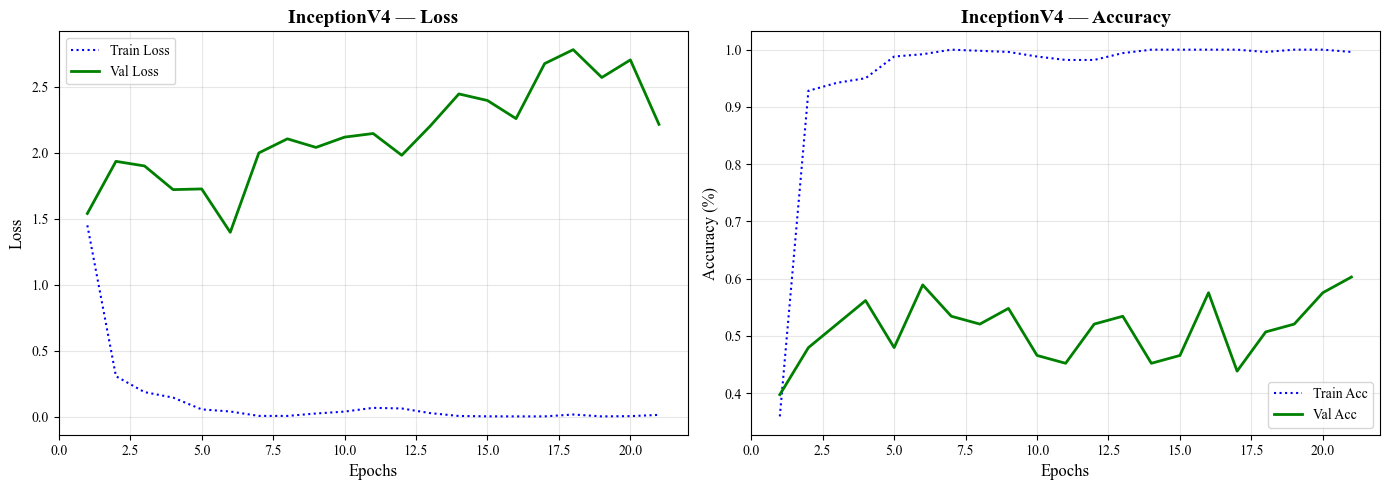


Running inference on test set...

  CLASSIFICATION REPORT — InceptionV4 (Test Set)
                             accuracy precision    recall  f1-score
-------------------------------------------------------------------
  B0A Pointing (one finger)    0.5500    0.5238    0.5500    0.5366
               G03 Throw up    0.0000    0.0000    0.0000    0.0000
             G04 Throw down    0.5000    0.4000    0.5000    0.4444
            G06 Throw right    0.2500    0.1429    0.2500    0.1818
             G07 Open twice    0.0000    0.0000    0.0000    0.0000
-------------------------------------------------------------------
                    Average    0.2600    0.2133    0.2600    0.2326

Saved confusion_matrix.png


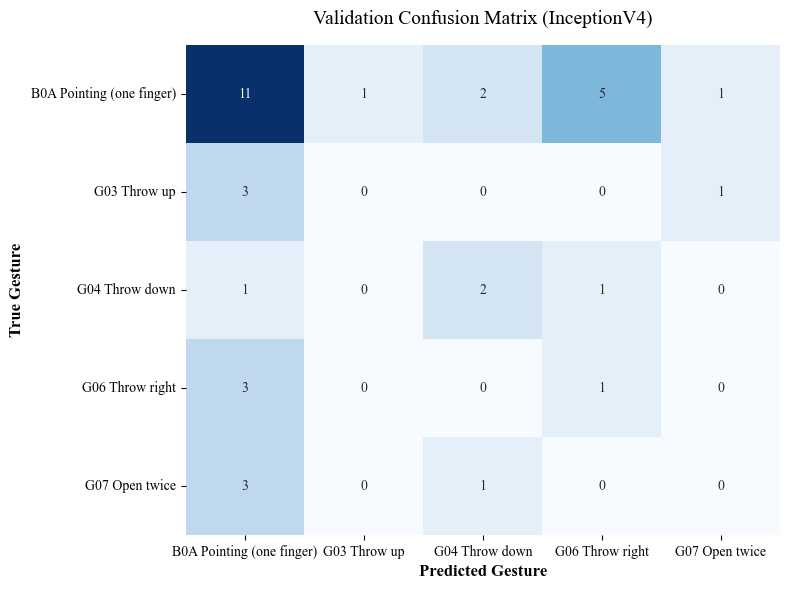

Saved f1_scores_bar.png


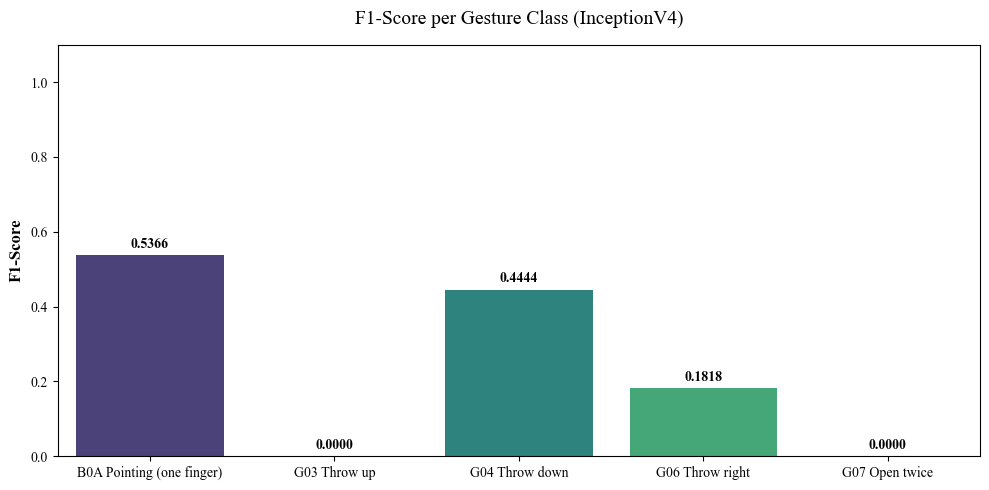

In [15]:
# ────────────────────────────────────────────────────────────────────────────────
# 16 Evaluate — matches EfficientNetB3 formatting
# ────────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman']

# Load training history from checkpoint if not in session
if 'training_history' not in dir() or training_history is None:
    ckpt = torch.load(os.path.join(CONFIG['CHECKPOINT_DIR'], 'best_model.pt'),
                      map_location=CONFIG['DEVICE'], weights_only=False)
    training_history = ckpt.get('training_history', None)

# VISUAL 1: Convergence Curves
if training_history:
    epochs_range = range(1, len(training_history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, training_history["train_loss"], label='Train Loss', color='blue', linestyle=':')
    ax1.plot(epochs_range, training_history["val_loss"],   label='Val Loss',   color='green', linewidth=2)
    ax1.set_title('InceptionV4 — Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12); ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs_range, training_history["train_acc"], label='Train Acc', color='blue', linestyle=':')
    ax2.plot(epochs_range, training_history["val_acc"],   label='Val Acc',   color='green', linewidth=2)
    ax2.set_title('InceptionV4 — Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12); ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['CHECKPOINT_DIR'], 'training_convergence.png'), dpi=300, bbox_inches='tight')
    print("Saved training_convergence.png")
    plt.show()
else:
    print("No training history found — retrain to generate convergence curves.")

# Inference on test set
print("\nRunning inference on test set...")
test_loader = DataLoader(dataset_test, batch_size=CONFIG['BATCH_SIZE'],
                         num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for frames, labels in test_loader:
        frames = frames.to(CONFIG['DEVICE'], non_blocking=True)
        logits = model(frames)
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = CONFIG['CLASS_NAMES']

# Classification report table
cm          = confusion_matrix(all_labels, all_preds)
report_dict = classification_report(all_labels, all_preds,
                                    target_names=class_names, output_dict=True)
row_sums      = cm.sum(axis=1)
per_class_acc = np.where(row_sums > 0, cm.diagonal() / row_sums, 0.0)

col_headers = ["accuracy", "precision", "recall", "f1-score"]
rows = []
for i, name in enumerate(class_names):
    d = report_dict[name]
    rows.append([per_class_acc[i], d["precision"], d["recall"], d["f1-score"]])
avg_row = np.mean(rows, axis=0).tolist()

col_w   = max(len(n) for n in class_names) + 2
num_w   = 10
header  = f"{'':>{col_w}}" + "".join(f"{h:>{num_w}}" for h in col_headers)
divider = "-" * (col_w + num_w * len(col_headers))

print("\n" + "=" * len(divider))
print("  CLASSIFICATION REPORT — InceptionV4 (Test Set)")
print("=" * len(divider))
print(header)
print(divider)
for name, row in zip(class_names, rows):
    print(f"{name:>{col_w}}" + "".join(f"{v:>{num_w}.4f}" for v in row))
print(divider)
print(f"{'Average':>{col_w}}" + "".join(f"{v:>{num_w}.4f}" for v in avg_row))
print("=" * len(divider))

# VISUAL 2: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix (InceptionV4)', fontsize=14, pad=15)
plt.ylabel('True Gesture',      fontsize=12, fontweight='bold')
plt.xlabel('Predicted Gesture', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['CHECKPOINT_DIR'], 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
print("\nSaved confusion_matrix.png")
plt.show()

# VISUAL 3: F1-Score Bar Chart
f1_scores = [report_dict[c]["f1-score"] for c in class_names]
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_names, y=f1_scores, palette='viridis')
plt.title('F1-Score per Gesture Class (InceptionV4)', fontsize=14, pad=15)
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.02, f"{v:.4f}", color='black', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['CHECKPOINT_DIR'], 'f1_scores_bar.png'), dpi=300, bbox_inches='tight')
print("Saved f1_scores_bar.png")
plt.show()